# Coding etiquette

The following information will provide better insight for customer profiling in terms of ads, bonus programs, and sales information.
* 01. Import libraries
* 02. Import data
* 03. Addressing Personally Identifiable Information (PII)
* 04. Create regional segmentation of the data
* 05. Drop low-activity customers from data

## 1. Import libraries

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

## 2. Import data

In [4]:
# Import pkl data 
path = '/Users/bobbi/Careerfoundry/InstacartBasketAnalysis_01_25'

ords_prods_costumer = pd.read_pickle(os.path.join(path, '02 Data', 'Prepared data', 'ords_prods_customer.pkl'))

In [5]:
ords_prods_costumer.head()

,order_id,user_id,order_number,orders_day_of_week,order_hour_of_day,days_since_last_order,product_id,add_to_cart_order,reordered,product_name,...,ords_flag,first_name,last_name,gender,state,age,date_joined,n_dependants,fam_status,income
0,2539329,1,1,2,8,NaN,196,1,0,Soda,...,Non-frequent customer,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423
1,2539329,1,1,2,8,NaN,14084,2,0,Organic Unsweetened Vanilla Almond Milk,...,Non-frequent customer,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423
2,2539329,1,1,2,8,NaN,12427,3,0,Original Beef Jerky,...,Non-frequent customer,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423
3,2539329,1,1,2,8,NaN,26088,4,0,Aged White Cheddar Popcorn,...,Non-frequent customer,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423
4,2539329,1,1,2,8,NaN,26405,5,0,XL Pick-A-Size Paper Towel Rolls,...,Non-frequent customer,Linda,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423


## 3. Addressing Personally Identifiable Information (PII)

Under GDPR law, any column within a dataset that could potentially be traced back to a specific individual is considered Personally Identifiable Information (PII). This includes names, email addresses, physical addresses, and phone numbers.

In Instacart’s dataset, under the customer data, the columns first_name and last_name are found, which contain customers' names. These are classified as PII since they can be directly linked to an individual.

While income alone is not typically considered PII, it can contribute to identifying an individual when combined with other information such as names, addresses, or account numbers. Similarly, family status (e.g., marital status, number of dependents) is classified as Sensitive Personal Data under some regulations, as it can reveal aspects of a person's relationships or household structure. 

To ensure GDPR compliance while still using these fields for analysis, I am anonymizing the dataset by removing the first_name and last_name columns, thereby eliminating direct identifiers while retaining valuable demographic insights.

In [8]:
# Drop columns to anonymise data
df_anonim = ords_prods_costumer.drop(columns=['first_name', 'last_name'])

df_anonim.head(5)

,order_id,user_id,order_number,orders_day_of_week,order_hour_of_day,days_since_last_order,product_id,add_to_cart_order,reordered,product_name,...,loyalty_flag,spending_flag,ords_flag,gender,state,age,date_joined,n_dependants,fam_status,income
0,2539329,1,1,2,8,NaN,196,1,0,Soda,...,New customer,Low spender,Non-frequent customer,Female,Alabama,31,2/17/2019,3,married,40423
1,2539329,1,1,2,8,NaN,14084,2,0,Organic Unsweetened Vanilla Almond Milk,...,New customer,Low spender,Non-frequent customer,Female,Alabama,31,2/17/2019,3,married,40423
2,2539329,1,1,2,8,NaN,12427,3,0,Original Beef Jerky,...,New customer,Low spender,Non-frequent customer,Female,Alabama,31,2/17/2019,3,married,40423
3,2539329,1,1,2,8,NaN,26088,4,0,Aged White Cheddar Popcorn,...,New customer,Low spender,Non-frequent customer,Female,Alabama,31,2/17/2019,3,married,40423
4,2539329,1,1,2,8,NaN,26405,5,0,XL Pick-A-Size Paper Towel Rolls,...,New customer,Low spender,Non-frequent customer,Female,Alabama,31,2/17/2019,3,married,40423


## 4. Create regional segmentation of the data

Based on the State column a Region column will be created following regional divisions used by the United States Census Bureau

In [11]:
# Region division following US Census Bureau
Northeast = ('Maine','New Hampshire','Vermont','Massachusetts','Rhode Island','Connecticut','New York',
             'Pennsylvania','New Jersey')
Midwest = ('Wisconsin','Michigan','Illinois','Indiana','Ohio','North Dakota','South Dakota','Nebraska','Kansas',
           'Minnesota','Iowa','Missouri')
South = ('Delaware','Maryland','District of Columbia','Virginia','West Virginia','North Carolina','South Carolina',
         'Georgia',' Florida','Kentucky','Tennessee','Alabama','Oklahoma','Texas','Arkansas','Louisiana')
West = ('Idaho','Montana','Wyoming','Nevada','Utah','Colorado','Arizona','New Mexico','Alaska','Washington','Oregon',
        'California','Hawaii')

In [12]:
# Create a new 'region' column to map and allocate regions
df_anonim.loc[df_anonim['state'].isin(Northeast), 'region'] = 'Northeast'
df_anonim.loc[df_anonim['state'].isin(Midwest), 'region'] = 'Midwest'
df_anonim.loc[df_anonim['state'].isin(South), 'region'] = 'South'
df_anonim.loc[df_anonim['state'].isin(West), 'region'] = 'West'

In [13]:
# Check head
df_anonim.head(5)

,order_id,user_id,order_number,orders_day_of_week,order_hour_of_day,days_since_last_order,product_id,add_to_cart_order,reordered,product_name,...,spending_flag,ords_flag,gender,state,age,date_joined,n_dependants,fam_status,income,region
0,2539329,1,1,2,8,NaN,196,1,0,Soda,...,Low spender,Non-frequent customer,Female,Alabama,31,2/17/2019,3,married,40423,South
1,2539329,1,1,2,8,NaN,14084,2,0,Organic Unsweetened Vanilla Almond Milk,...,Low spender,Non-frequent customer,Female,Alabama,31,2/17/2019,3,married,40423,South
2,2539329,1,1,2,8,NaN,12427,3,0,Original Beef Jerky,...,Low spender,Non-frequent customer,Female,Alabama,31,2/17/2019,3,married,40423,South
3,2539329,1,1,2,8,NaN,26088,4,0,Aged White Cheddar Popcorn,...,Low spender,Non-frequent customer,Female,Alabama,31,2/17/2019,3,married,40423,South
4,2539329,1,1,2,8,NaN,26405,5,0,XL Pick-A-Size Paper Towel Rolls,...,Low spender,Non-frequent customer,Female,Alabama,31,2/17/2019,3,married,40423,South


In [14]:
# Frequency 
df_anonim.groupby('region')['user_id'].nunique()

region
Midwest      48519
Northeast    36388
South        60650
West         52565
Name: user_id, dtype: int64

I counted the unique customers per region as the numbers without filtering through user_id are higher and not realistic as they are attached to the number of products and not the number of real customers

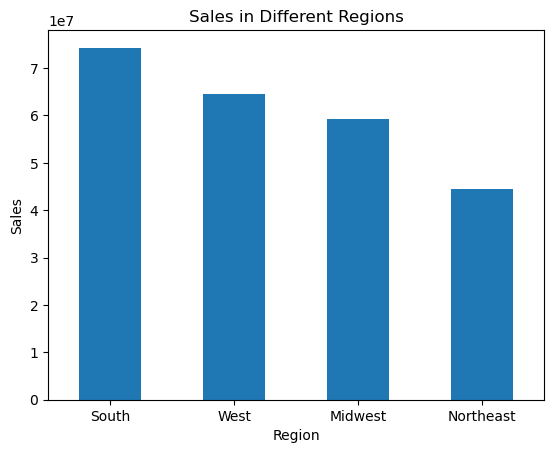

In [16]:
# Create users per region bar chart 
bar_user_region = df_anonim.groupby('region')['prices'].sum().sort_values(ascending=False).plot(kind='bar')
bar_user_region.set_xlabel('Region')
bar_user_region.set_ylabel('Sales')
bar_user_region.set_title('Sales in Different Regions')
plt.xticks(rotation=0)
plt.show()

This bar chart visually highlights how sales are distributed across different regions. The South region has a significant share of the total sales, and the Northeast is at the lower end of the spectrum. This correlates with the number of customers in each reagion as the south regions has almost doble the customers than the northeast region.

In [30]:
# Export bar chart
bar_user_region.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations', 'bar_user_region.png'))

## 4. Drop low-activity customers from data

As the CFO isn't interested in customers who don't generate much revenue for the app low-activity customers are going to be drop from the data and not be included in further analysis. Customers will be considered as low-activity custumers when they have less than 5 orders.

In [35]:
print(df_anonim.columns)

Index(['order_id', 'user_id', 'order_number', 'orders_day_of_week',
       'order_hour_of_day', 'days_since_last_order', 'product_id',
       'add_to_cart_order', 'reordered', 'product_name', 'aisle_id',
       'department_id', 'prices', 'busiest_days', 'busiest_period_of_day',
       'loyalty_flag', 'spending_flag', 'ords_flag', 'gender', 'state', 'age',
       'date_joined', 'n_dependants', 'fam_status', 'income', 'region'],
      dtype='object')


I am going to calculate a max_order column to calculate how many orders each customer has so I can create an 'exclude_flag' for low-activity customers

In [38]:
# Create a loyality flag column
df_anonim['max_order'] = df_anonim.groupby(['user_id'])['order_number'].transform(np.max)

# Making an exclusion flag
df_anonim['exclude_flag'] = df_anonim['max_order'] < 5

# New dataframe withpit low-activity customer
df_excluded = df_anonim[~df_anonim['exclude_flag']]

df_excluded.head()

/var/folders/bs/25x482152nx68y1wp8l2g42c0000gn/T/ipykernel_9114/3021550811.py:2: FutureWarning: The provided callable <function max at 0x113500680> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  df_anonim['max_order'] = df_anonim.groupby(['user_id'])['order_number'].transform(np.max)


,order_id,user_id,order_number,orders_day_of_week,order_hour_of_day,days_since_last_order,product_id,add_to_cart_order,reordered,product_name,...,gender,state,age,date_joined,n_dependants,fam_status,income,region,max_order,exclude_flag
0,2539329,1,1,2,8,NaN,196,1,0,Soda,...,Female,Alabama,31,2/17/2019,3,married,40423,South,10,False
1,2539329,1,1,2,8,NaN,14084,2,0,Organic Unsweetened Vanilla Almond Milk,...,Female,Alabama,31,2/17/2019,3,married,40423,South,10,False
2,2539329,1,1,2,8,NaN,12427,3,0,Original Beef Jerky,...,Female,Alabama,31,2/17/2019,3,married,40423,South,10,False
3,2539329,1,1,2,8,NaN,26088,4,0,Aged White Cheddar Popcorn,...,Female,Alabama,31,2/17/2019,3,married,40423,South,10,False
4,2539329,1,1,2,8,NaN,26405,5,0,XL Pick-A-Size Paper Towel Rolls,...,Female,Alabama,31,2/17/2019,3,married,40423,South,10,False


In [40]:
# Export low-activity customer data sample
df_low_activity = df_anonim[df_anonim['exclude_flag']]

df_low_activity.head()

,order_id,user_id,order_number,orders_day_of_week,order_hour_of_day,days_since_last_order,product_id,add_to_cart_order,reordered,product_name,...,gender,state,age,date_joined,n_dependants,fam_status,income,region,max_order,exclude_flag
360,2717275,5,1,3,12,NaN,15349,1,0,Organic Raw Agave Nectar,...,Female,California,75,10/8/2018,0,divorced/widowed,115242,West,4,True
361,2717275,5,1,3,12,NaN,21413,2,0,Organic Soba,...,Female,California,75,10/8/2018,0,divorced/widowed,115242,West,4,True
362,2717275,5,1,3,12,NaN,48775,3,0,Organic Red Cabbage,...,Female,California,75,10/8/2018,0,divorced/widowed,115242,West,4,True
363,2717275,5,1,3,12,NaN,28289,4,0,Organic Shredded Carrots,...,Female,California,75,10/8/2018,0,divorced/widowed,115242,West,4,True
364,2717275,5,1,3,12,NaN,8518,5,0,Organic Red Onion,...,Female,California,75,10/8/2018,0,divorced/widowed,115242,West,4,True


In [42]:
df_low_activity.to_pickle(os.path.join(path, '02 Data', 'Prepared Data', 'low_activity_customer.pkl'))

In [46]:
df_excluded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30964564 entries, 0 to 32404858
Data columns (total 28 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   order_id               int64  
 1   user_id                int64  
 2   order_number           int64  
 3   orders_day_of_week     int64  
 4   order_hour_of_day      int64  
 5   days_since_last_order  float64
 6   product_id             int64  
 7   add_to_cart_order      int64  
 8   reordered              int64  
 9   product_name           object 
 10  aisle_id               int64  
 11  department_id          int64  
 12  prices                 float64
 13  busiest_days           object 
 14  busiest_period_of_day  object 
 15  loyalty_flag           object 
 16  spending_flag          object 
 17  ords_flag              object 
 18  gender                 object 
 19  state                  object 
 20  age                    int64  
 21  date_joined            object 
 22  n_dependants         

I am going to create a subset to be able to work on visualizations and following explorations and then I am going to minimize the data.

In [52]:
# Subset
df_subset = df_excluded.drop(columns=['reordered', 'exclude_flag'])

In [54]:
# Minimize
df_subset['order_id'] = df_subset['order_id'].astype('int32')
df_subset['user_id'] = df_subset['user_id'].astype('int32')
df_subset['order_number'] = df_subset['order_number'].astype('int8')
df_subset['orders_day_of_week'] = df_subset['orders_day_of_week'].astype('int8')
df_subset['order_hour_of_day'] = df_subset['order_hour_of_day'].astype('int8')
df_subset['days_since_last_order'] = df_subset['days_since_last_order'].astype('float32')
df_subset['product_id'] = df_subset['product_id'].astype('int32')
df_subset['add_to_cart_order'] = df_subset['add_to_cart_order'].astype('int32')
df_subset['aisle_id'] = df_subset['aisle_id'].astype('int32')
df_subset['department_id'] = df_subset['department_id'].astype('int32')
df_subset['prices'] = df_subset['prices'].astype('float32')
df_subset['age'] = df_subset['age'].astype('int8')
df_subset['n_dependants'] = df_subset['n_dependants'].astype('int8')
df_subset['income'] = df_subset['income'].astype('int32')
df_subset['max_order'] = df_subset['max_order'].astype('int32')

In [56]:
df_subset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30964564 entries, 0 to 32404858
Data columns (total 26 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   order_id               int32  
 1   user_id                int32  
 2   order_number           int8   
 3   orders_day_of_week     int8   
 4   order_hour_of_day      int8   
 5   days_since_last_order  float32
 6   product_id             int32  
 7   add_to_cart_order      int32  
 8   product_name           object 
 9   aisle_id               int32  
 10  department_id          int32  
 11  prices                 float32
 12  busiest_days           object 
 13  busiest_period_of_day  object 
 14  loyalty_flag           object 
 15  spending_flag          object 
 16  ords_flag              object 
 17  gender                 object 
 18  state                  object 
 19  age                    int8   
 20  date_joined            object 
 21  n_dependants           int8   
 22  fam_status           

In [68]:
# Export data
df_subset.to_pickle(os.path.join(path, '02 Data', 'Prepared Data', 'subset_ords_prods_cust.pkl'))